In [18]:
import uproot
import matplotlib.pyplot as plt
import numpy as np
import compress_pickle as pickle  
import mplhep as hep
import math
from scipy.optimize import curve_fit
import compress_pickle
import pickle
import gzip
hep.style.use("CMS")
from helpers import *

In [19]:
path_to_result = "/media/miguel/Elements_2024/AI_data/results_and_models/ePIC_DIS_results/testing_dis/"

In [20]:
# Will likely need to change name of npz file for your use case
npz_unpacked = np.load(path_to_result+"/predictions_appended_test.npz", allow_pickle=True) 
predictions_unnormalized = npz_unpacked['outputs_scaled'].item()
targets_unnormalized = npz_unpacked['targets_scaled'].item()

targets_E_minus_pz = targets_unnormalized["E_minus_pz"]
targets_pt = targets_unnormalized["transverse_momentum"]

predictions_E_minus_pz = predictions_unnormalized["E_minus_pz"]
predictions_pt = predictions_unnormalized["transverse_momentum"]

meta_info = npz_unpacked['meta']

In [141]:
import vector
import uproot
def rotateY(xdata, zdata, angle):
    s = np.sin(angle)
    c = np.cos(angle)
    rotatedz = c*zdata - s*xdata
    rotatedx = s*zdata + c*xdata
    return rotatedx, rotatedz
def get_strawman_reco(meta_info, eta_low, eta_high):
    test_files = meta_info[:,0]
    file_to_event_numbers_dict = {}
    for file_name in test_files:
        file_to_event_numbers_dict[file_name] = [] 
    for data in meta_info:
        file_name = data[0]
        event_number = data[1]    
        file_to_event_numbers_dict[file_name].append(event_number)
    
    total_pt, total_E_minus_pz = np.array([]), np.array([])
    truth_total_pt, truth_total_E_minus_pz = np.array([]), np.array([])
    for file_name, event_numbers in file_to_event_numbers_dict.items():
        event_numbers = np.asarray(event_numbers, dtype=int)
        
        with uproot.open(file_name+":events") as f:
            mcparticles_arrays = f.arrays(["MCParticles.momentum.x", "MCParticles.momentum.y", "MCParticles.momentum.z", "MCParticles.mass", "MCParticles.generatorStatus"])[event_numbers]
            mcparticles_arrays = mcparticles_arrays[mcparticles_arrays["MCParticles.generatorStatus"]==1]
            momentum_x, momentum_z = rotateY(mcparticles_arrays["MCParticles.momentum.x"], mcparticles_arrays["MCParticles.momentum.z"], .025)
            
            momentum_y = mcparticles_arrays["MCParticles.momentum.y"]
            momentum = np.sqrt(momentum_x**2 + momentum_y**2 + momentum_z**2)
            
            theta = np.arccos(momentum_z/momentum)
            eta = -np.log(np.tan(theta/2))
            eta_mask = (eta>3) & (eta<4)
            momentum_x = momentum_x[eta_mask]
            momentum_y = momentum_y[eta_mask]
            momentum_z = momentum_z[eta_mask]
            momentum = momentum[eta_mask]
            mass = mcparticles_arrays["MCParticles.mass"][eta_mask]
            energy = np.sqrt(momentum**2 + mass**2)
            energy_minus_pz = energy - momentum_z
            truth_E_minus_pz = ak.sum(energy_minus_pz, axis=1)
            px_sum = ak.sum(momentum_x, axis=-1)
            py_sum = ak.sum(momentum_y, axis=-1)
            truth_pt = np.sqrt(px_sum**2 + py_sum**2)
            truth_total_pt = np.concatenate((truth_total_pt, truth_pt))
            truth_total_E_minus_pz = np.concatenate((truth_total_E_minus_pz, truth_E_minus_pz))
            
            hcal_arrays = f.arrays(['LFHCALRecHits.energy',
                                         'LFHCALRecHits.position.x',
                                         'LFHCALRecHits.position.y',
                                         'LFHCALRecHits.position.z']
                                       )[event_numbers]



            hcal_insert_arrays = f.arrays(['HcalEndcapPInsertRecHits.energy',
                                                'HcalEndcapPInsertRecHits.position.x',
                                                'HcalEndcapPInsertRecHits.position.y',
                                                'HcalEndcapPInsertRecHits.position.z']
                                              )[event_numbers]
            ecal_arrays = f.arrays(['EcalEndcapPRecHits.energy',
                                         'EcalEndcapPRecHits.position.x',
                                         'EcalEndcapPRecHits.position.y',
                                         'EcalEndcapPRecHits.position.z']
                                       )[event_numbers]

            ecal_insert_arrays = f.arrays(['EcalEndcapPInsertRecHits.energy',
                                                'EcalEndcapPInsertRecHits.position.x',
                                                'EcalEndcapPInsertRecHits.position.y',
                                                'EcalEndcapPInsertRecHits.position.z']
                                              )[event_numbers]
            cal_energy = ak.concatenate((hcal_arrays['LFHCALRecHits.energy'],
                             hcal_insert_arrays['HcalEndcapPInsertRecHits.energy']/.02,
                             ecal_arrays['EcalEndcapPRecHits.energy'],
                             ecal_insert_arrays['EcalEndcapPInsertRecHits.energy']),
                            axis=-1)

            cal_posx = ak.concatenate((hcal_arrays['LFHCALRecHits.position.x'],
                                       hcal_insert_arrays['HcalEndcapPInsertRecHits.position.x'],
                                       ecal_arrays['EcalEndcapPRecHits.position.x'],
                                       ecal_insert_arrays['EcalEndcapPInsertRecHits.position.x']),
                                      axis=-1)

            cal_posy = ak.concatenate((hcal_arrays['LFHCALRecHits.position.y'],
                                       hcal_insert_arrays['HcalEndcapPInsertRecHits.position.y'],
                                       ecal_arrays['EcalEndcapPRecHits.position.y'],
                                       ecal_insert_arrays['EcalEndcapPInsertRecHits.position.y']),
                                      axis=-1)
            cal_posz = ak.concatenate((hcal_arrays['LFHCALRecHits.position.z'],
                                       hcal_insert_arrays['HcalEndcapPInsertRecHits.position.z'],
                                       ecal_arrays['EcalEndcapPRecHits.position.z'],
                                       ecal_insert_arrays['EcalEndcapPInsertRecHits.position.z']),
                                      axis=-1)
            
            cal_pos_vec = vector.zip({
                "x": cal_posx,
                "y": cal_posy,
                "z": cal_posz,
            })

            cal_pos_unit = cal_pos_vec.unit()
            cal_mom_vec = cal_energy*cal_pos_unit
            
            cal_mom_vec_star = cal_mom_vec.rotateY(25./1000.)
            cal_energy_star = cal_mom_vec_star.mag #should be same as unrotated
            cal_px_star = cal_mom_vec_star.x
            cal_py_star = cal_mom_vec_star.y #should be same as unrotated
            cal_pz_star = cal_mom_vec_star.z
            cal_eta_star = cal_mom_vec_star.eta
            cal_empz_star = cal_energy_star - cal_pz_star
            cal_e34 = cal_energy_star[(cal_eta_star>eta_low) & (cal_eta_star<eta_high)] #should be same as using unrotated energy
            cal_e34_sum = ak.sum(cal_e34,axis=-1)

            cal_empz3 = cal_empz_star[(cal_eta_star>eta_low) & (cal_eta_star<eta_high)]
            cal_empz3_sum = ak.sum(cal_empz3,axis=-1)

            cal_px34_sum = ak.sum(cal_px_star[(cal_eta_star>eta_low) & (cal_eta_star<eta_high)],axis=-1)
            cal_py34_sum = ak.sum(cal_py_star[(cal_eta_star>eta_low) & (cal_eta_star<eta_high)],axis=-1)
            cal_pt34_sum = np.sqrt( cal_px34_sum*cal_px34_sum + cal_py34_sum*cal_py34_sum )
            
            total_pt = np.concatenate((total_pt, cal_pt34_sum))
            total_E_minus_pz = np.concatenate((total_E_minus_pz, cal_empz3_sum))
            
    return total_pt, total_E_minus_pz, truth_total_E_minus_pz, truth_total_pt

In [153]:
reco_total_pt, reco_E_minus_pz, truth_E_minus_pz, truth_total_pt = get_strawman_reco(meta_info, eta_low=3, eta_high = 4)

Text(0, 1, 'Counts (log)')

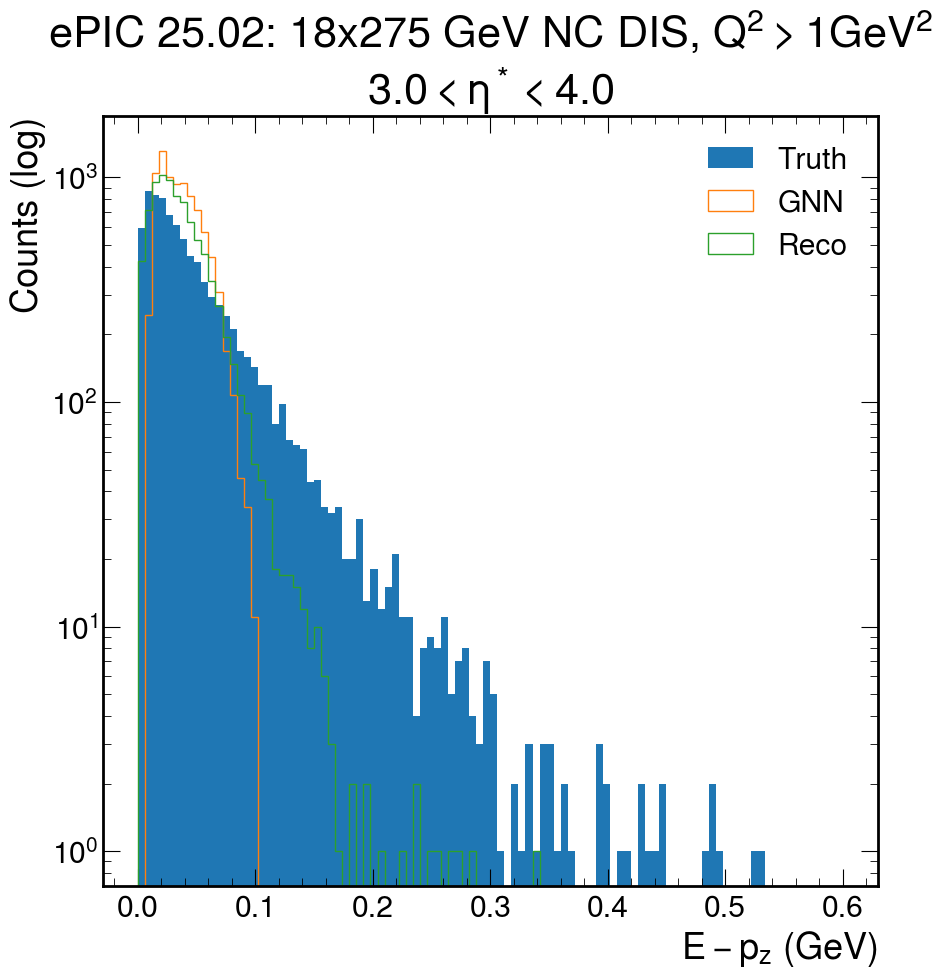

In [154]:
plt.hist(truth_E_minus_pz, bins=100, range=(0,.6), label="Truth")
plt.hist(predictions_E_minus_pz, bins=100,range=(0,.6), label="GNN", histtype='step')
plt.hist(reco_E_minus_pz, bins=100,range=(0,.6), label="Reco", histtype='step')
plt.xlabel("$E-p_z$ (GeV)")
plt.yscale('log')
plt.title("ePIC 25.02: 18x275 GeV NC DIS, $Q^2 > 1 GeV^2$\n$3.0<\eta^*<4.0$")
plt.legend()
plt.ylabel("Counts (log)")

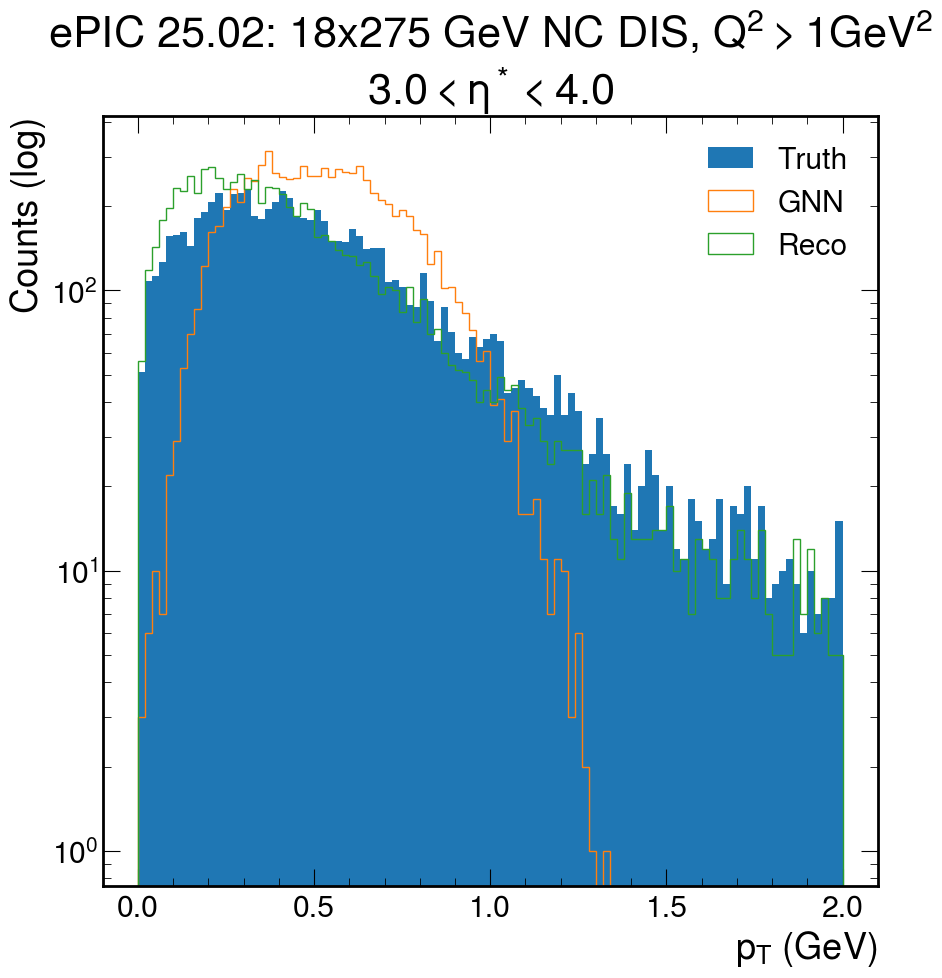

In [155]:
plt.hist(targets_pt, bins=100, range=(0,2),label="Truth")
plt.hist(predictions_pt, bins=100, range=(0,2), label="GNN", histtype='step')
plt.hist(reco_total_pt, bins=100, range=(0,2), label="Reco", histtype='step')

plt.xlabel("$p_{T}$ (GeV)")
plt.yscale('log')
plt.title("ePIC 25.02: 18x275 GeV NC DIS, $Q^2 > 1 GeV^2$\n$3.0<\eta^*<4.0$")
plt.ylabel("Counts (log)")
plt.legend()
# plt.xlim(0,2)

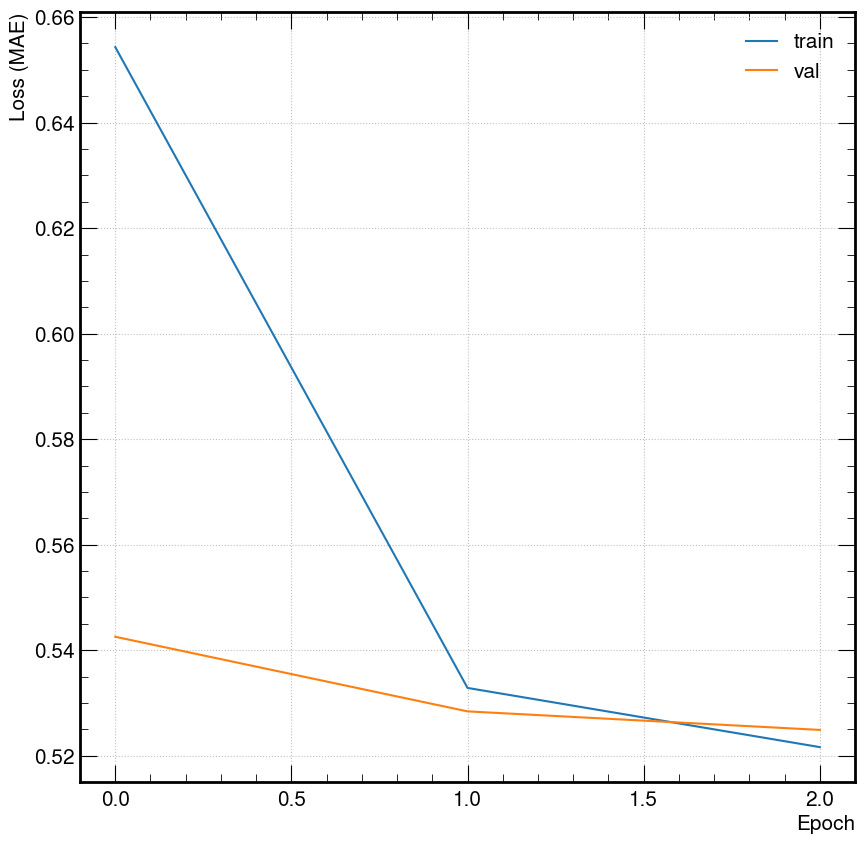

In [156]:
npz_unpacked_loss = np.load(path_to_result + "/losses.npz")

train_loss = npz_unpacked_loss['training']
val_loss = npz_unpacked_loss['validation']

val_mean_loss=np.mean(val_loss, axis=1)
train_mean_loss=np.mean(train_loss, axis=1)

plt.plot(train_mean_loss,label='train')

plt.plot(val_mean_loss, label='val')
plt.xlabel("Epoch", fontsize=15)
plt.ylabel("Loss (MAE)", fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.legend(fontsize=15)
plt.grid()